In [ ]:
!pip install --upgrade xee

In [ ]:
!pip install -U geemap

In [3]:
import ee

In [4]:
ee.Authenticate()
ee.Initialize(project = "ee-grmntfrancis0",
             opt_url = 'https://earthengine-highvolume.googleapis.com'
              )

In [5]:
import geemap

In [6]:
map = geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [7]:
roi = map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -169.37974,
                          -79.304679
                        ],
                        [
                          -169.37974,
                          71.74299
                        ],
                        [
                          194.302229,
                          71.74299
                        ],
                        [
                          194.302229,
                          -79.304679
                        ],
                        [
                          -169.37974,
                          -79.304679
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [12]:
pdsi = (ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")
    .filterDate("2010", "2025")
    .select("pdsi")
    .mean()
)
pdsi

In [24]:
import xarray as xr

In [25]:
ds = xr.open_dataset(
    pdsi,
    engine = "ee",
    crs = "EPSG:4326",
    geometry = roi,
    scale = 1

)
ds

<xarray.Dataset> Size: 222kB
Dimensions:  (time: 1, lon: 360, lat: 151)
Coordinates:
  * time     (time) int64 8B 0
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -78.8 -77.8 -76.8 -75.8 ... 68.2 69.2 70.2 71.2
Data variables:
    pdsi     (time, lon, lat) float32 217kB ...
Attributes:
    crs:      EPSG:4326

In [26]:
ds = ds.squeeze("time").drop_vars("time") * 0.01

In [ ]:
!pip install cartopy

In [28]:
import cartopy.crs as ccrs

In [29]:
import matplotlib.pyplot as plt

In [30]:
ds

<xarray.Dataset> Size: 222kB
Dimensions:  (lon: 360, lat: 151)
Coordinates:
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -78.8 -77.8 -76.8 -75.8 ... 68.2 69.2 70.2 71.2
Data variables:
    pdsi     (lon, lat) float32 217kB nan nan nan nan ... -0.2085 nan -3.159
Attributes:
    crs:      EPSG:4326

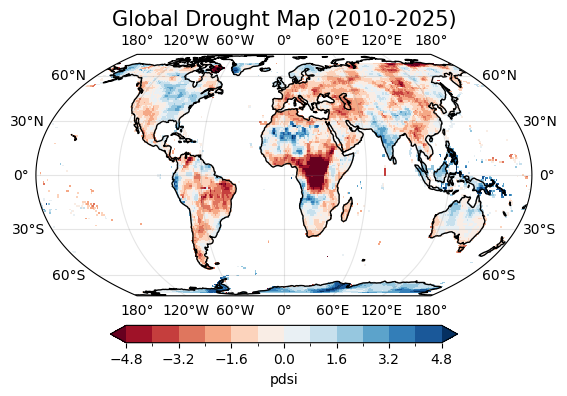

In [61]:
plt.figure()
ax = plt.axes(projection = ccrs.EqualEarth())
ds.pdsi.plot(
    x = "lon", y = "lat", transform =ccrs.PlateCarree(),
    robust = True, cmap = "RdBu", levels = 15, cbar_kwargs = {
        "orientation": "horizontal", "pad": 0.08, "shrink":0.7
    }
)

ax.coastlines(resolution = "110m")
ax.set_global()
ax.gridlines(draw_labels = True, alpha = 0.2, color = 'gray')
ax.set_title("Global Drought Map (2010-2025)", fontsize = 15)

plt.savefig("drought_map.png", dpi = 360, bbox_inches = "tight")